# Task 4: Mini Visualization Dashboard
## Titanic Dataset Analysis

**Internship:** Data Science with Python

### Objective
Create a mini dashboard using Matplotlib and Seaborn to communicate important insights from the Titanic dataset through visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(8,5)

## Load Dataset
Load the Titanic dataset and preview its contents.

In [2]:
df=pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Overview
Understand the structure and data types.

In [3]:
df.info()

df.describe()

df.shape

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


(891, 12)

## Missing Values
Check missing values before cleaning.

In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Data Cleaning
Handle missing values and remove duplicates.

In [18]:
# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df["Cabin"] = df["Cabin"].fillna("Unknown")

# Remove duplicate rows
df = df.drop_duplicates()

## Feature Engineering
Create new features for better analysis.

In [6]:
df["FamilySize"]=df["SibSp"]+df["Parch"]+1

df["IsAlone"]=np.where(df["FamilySize"]==1,1,0)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1


## Survival Distribution

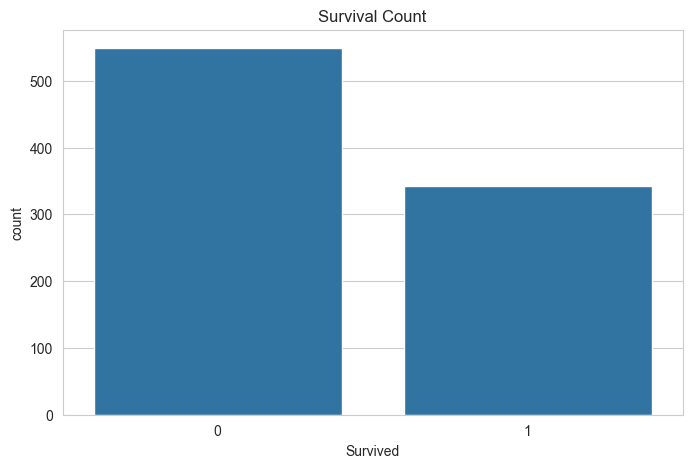

In [7]:
sns.countplot(data=df,x="Survived")
plt.title("Survival Count")
plt.show()

**Insight:** More passengers did not survive than survived.

## Survival by Gender

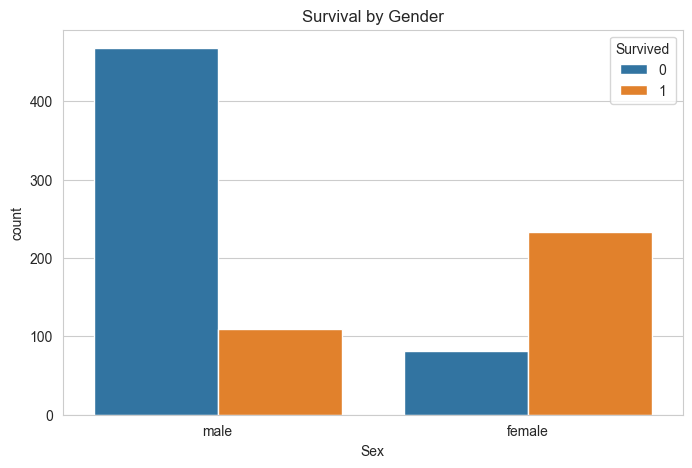

In [8]:
sns.countplot(data=df,x="Sex",hue="Survived")
plt.title("Survival by Gender")
plt.show()

**Insight:** Female passengers had a much higher survival rate than males.

## Passenger Class Distribution

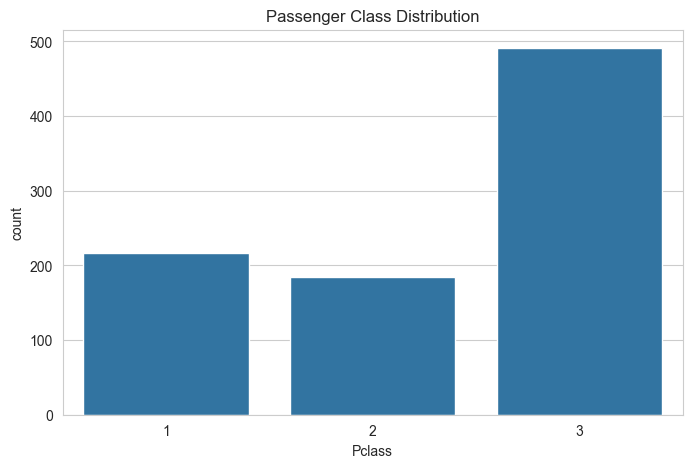

In [9]:
sns.countplot(data=df,x="Pclass")
plt.title("Passenger Class Distribution")
plt.show()

**Insight:** Most passengers travelled in Third Class.

## Survival by Passenger Class

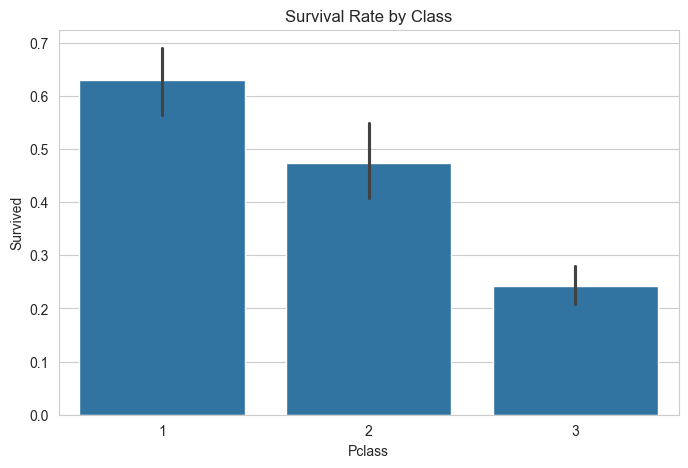

In [10]:
sns.barplot(data=df,x="Pclass",y="Survived")
plt.title("Survival Rate by Class")
plt.show()

**Insight:** First-class passengers had the highest survival rate.

## Age Distribution

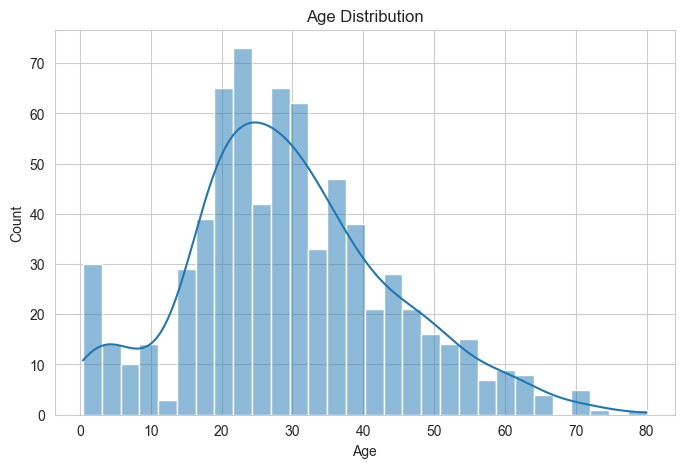

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"],bins=30,kde=True)
plt.title("Age Distribution")
plt.show()

**Insight:** Most passengers were between 20 and 40 years old.

## Fare Distribution

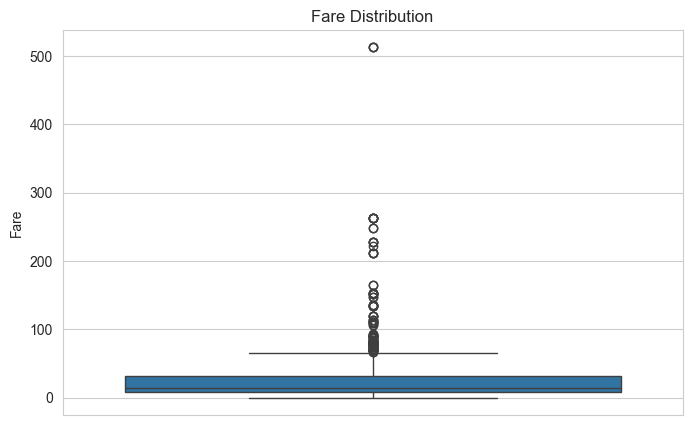

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["Fare"])
plt.title("Fare Distribution")
plt.show()

**Insight:** Ticket fares contain several high-value outliers.

## Correlation Heatmap

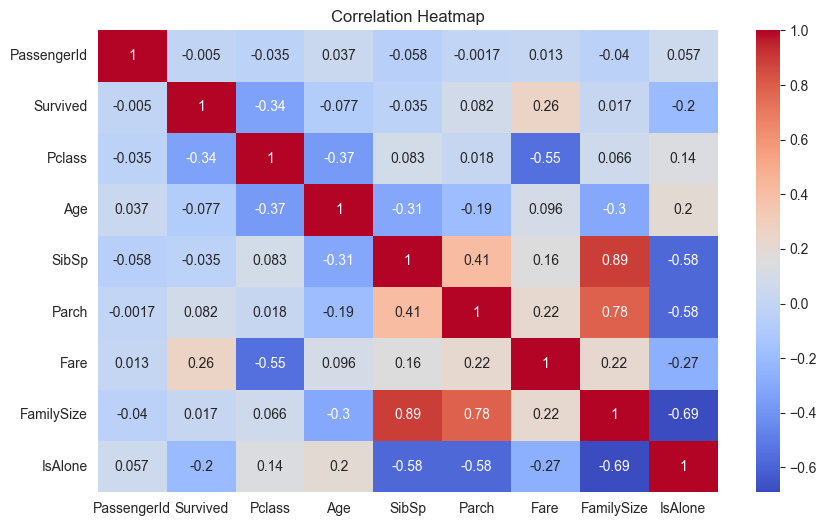

In [13]:
plt.figure(figsize=(10,6))

corr=df.select_dtypes(include=np.number).corr()

sns.heatmap(corr,annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

**Insight:** Passenger class has a negative relationship with survival, while fare has a positive relationship.

## Family Size vs Survival

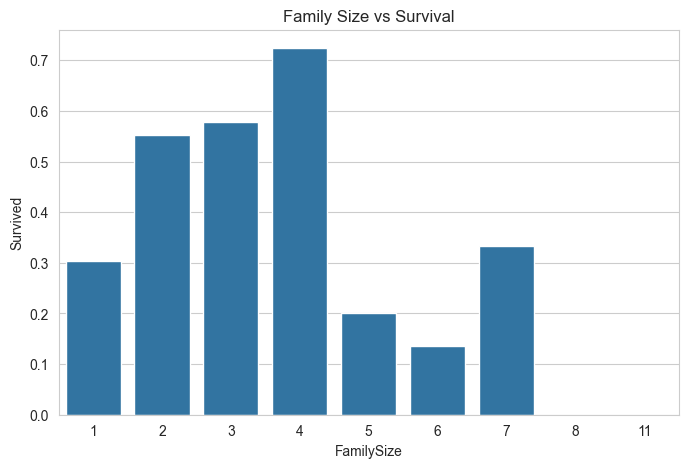

In [14]:
sns.barplot(data=df,x="FamilySize",y="Survived",errorbar=None)

plt.title("Family Size vs Survival")

plt.show()

**Insight:** Passengers travelling in small families generally had better survival chances.

## Survival by Embarkation Port

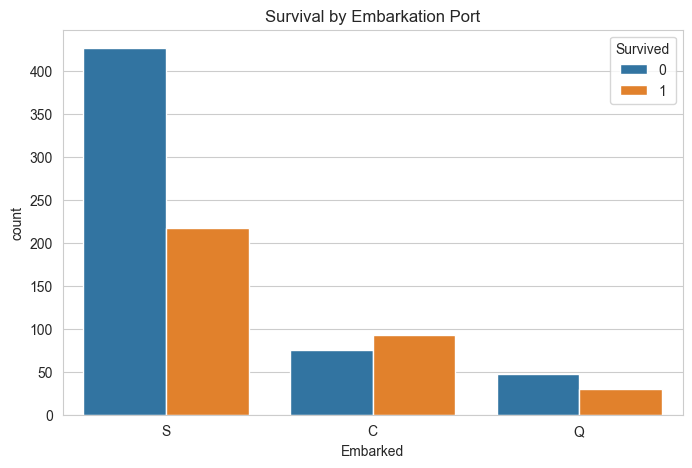

In [15]:
sns.countplot(data=df,x="Embarked",hue="Survived")

plt.title("Survival by Embarkation Port")

plt.show()

**Insight:** Survival varied across embarkation ports, with Cherbourg showing the highest proportion of survivors.

## Pairwise Relationships

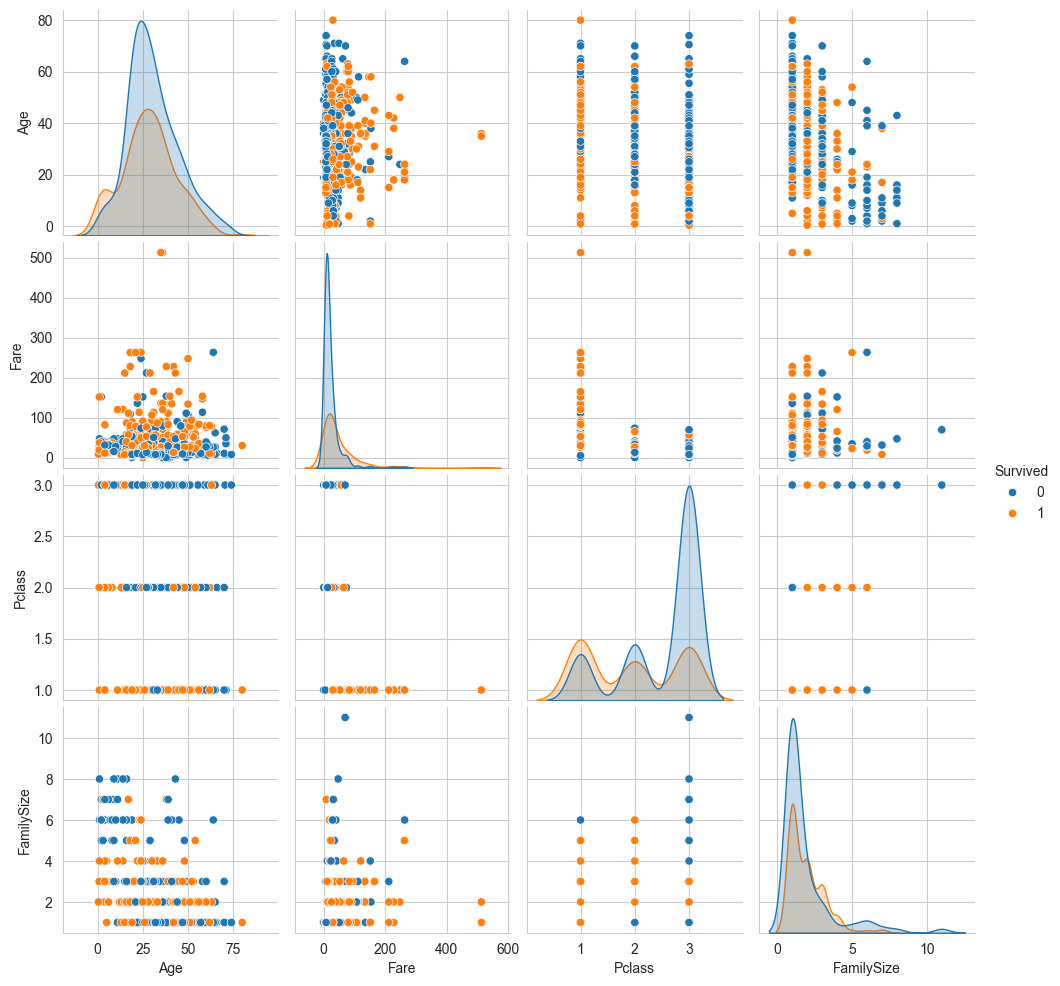

In [16]:
sns.pairplot(
    df[["Survived","Age","Fare","Pclass","FamilySize"]],
    hue="Survived"
)

plt.show()

**Insight:** Fare and passenger class separate survivors more clearly than age.

# Conclusion

- Females had the highest survival rate.
- First-class passengers survived more frequently.
- Most passengers belonged to the 20–40 age group.
- Higher ticket fares generally corresponded to higher survival.
- Small family groups had better survival chances than very large groups.
- Feature engineering using FamilySize and IsAlone improved the overall analysis.